<a href="https://colab.research.google.com/github/yogitaalone04-web/machine-learning-practicals/blob/main/Decision_Tree_Classification_Developer_Performance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

CS24D017: Yogita Alone

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.model_selection import train_test_split

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
path = "/content/drive/MyDrive/ML_Dataset/Developer_Performance_dataset_1000.csv"
df = pd.read_csv(path)

df.head()

,Hours_Coding,Lines_of_Code,Bugs_Found,Bugs_Fixed,AI_Usage_Hours,Sleep_Hours,Cognitive_Load,Coffee_Intake,Stress_Level,Task_Duration_Hours,Commits,Errors,Task_Success_Rate
0,7,416,9,7,6,5.9,92,7,99,10.5,20,3,34
1,4,269,16,13,5,5.1,85,2,100,9.5,17,8,36
2,11,439,3,0,2,6.2,38,2,55,18.3,35,2,79
3,8,472,15,9,4,4.2,26,5,30,12.6,28,4,94
4,5,265,19,16,5,8.1,82,6,82,7.0,25,9,33


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Hours_Coding         1000 non-null   int64  
 1   Lines_of_Code        1000 non-null   int64  
 2   Bugs_Found           1000 non-null   int64  
 3   Bugs_Fixed           1000 non-null   int64  
 4   AI_Usage_Hours       1000 non-null   int64  
 5   Sleep_Hours          1000 non-null   float64
 6   Cognitive_Load       1000 non-null   int64  
 7   Coffee_Intake        1000 non-null   int64  
 8   Stress_Level         1000 non-null   int64  
 9   Task_Duration_Hours  1000 non-null   float64
 10  Commits              1000 non-null   int64  
 11  Errors               1000 non-null   int64  
 12  Task_Success_Rate    1000 non-null   int64  
dtypes: float64(2), int64(11)
memory usage: 101.7 KB


In [5]:
df.shape

(1000, 13)

In [6]:
df.describe()

,Hours_Coding,Lines_of_Code,Bugs_Found,Bugs_Fixed,AI_Usage_Hours,Sleep_Hours,Cognitive_Load,Coffee_Intake,Stress_Level,Task_Duration_Hours,Commits,Errors,Task_Success_Rate
count,1000.00000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,5.84000,356.23400,9.876000,7.153000,2.961000,6.465800,56.933000,3.368000,66.410000,8.700100,17.253000,4.544000,56.578000
std,3.15854,188.15535,5.796052,5.468226,2.021278,1.439529,21.767506,2.342234,21.865452,5.992891,10.836901,2.820997,20.814879
min,1.00000,26.00000,0.000000,0.000000,0.000000,4.000000,20.000000,0.000000,30.000000,0.500000,1.000000,0.000000,30.000000
25%,3.00000,209.50000,5.000000,2.000000,1.000000,5.200000,38.000000,1.000000,48.000000,4.000000,9.000000,2.000000,37.000000
50%,6.00000,332.00000,10.000000,7.000000,3.000000,6.400000,57.000000,3.000000,66.000000,7.450000,14.000000,5.000000,55.500000
75%,9.00000,480.50000,15.000000,12.000000,5.000000,7.700000,76.000000,5.000000,86.000000,12.000000,23.000000,7.000000,74.000000
max,11.00000,993.00000,19.000000,19.000000,6.000000,9.000000,94.000000,7.000000,100.000000,27.500000,50.000000,9.000000,100.000000


In [7]:
df.columns

Index(['Hours_Coding', 'Lines_of_Code', 'Bugs_Found', 'Bugs_Fixed',
       'AI_Usage_Hours', 'Sleep_Hours', 'Cognitive_Load', 'Coffee_Intake',
       'Stress_Level', 'Task_Duration_Hours', 'Commits', 'Errors',
       'Task_Success_Rate'],
      dtype='object')

In [8]:
df.isnull().sum()

,0
Hours_Coding,0
Lines_of_Code,0
Bugs_Found,0
Bugs_Fixed,0
AI_Usage_Hours,0
Sleep_Hours,0
Cognitive_Load,0
Coffee_Intake,0
Stress_Level,0
Task_Duration_Hours,0


In [9]:
df.drop('number', axis=1, inplace=True, errors='ignore')
df.shape

(1000, 13)

In [10]:
before_rows = df.shape[0]
df = df.dropna()
after_rows = df.shape[0]

In [11]:
print("Before rows:", before_rows)
print("After rows:", after_rows)
print("Dropped rows:", before_rows - after_rows)

Before rows: 1000
After rows: 1000
Dropped rows: 0


In [16]:
df['Performance_Label'] = (df['Task_Success_Rate'] >= df['Task_Success_Rate'].mean()) * 1

In [17]:
X = df.drop(['Task_Success_Rate', 'Performance_Label'], axis=1)
Y = df['Performance_Label']

In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.3, random_state=42
)

In [19]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(
    criterion='gini',
    max_depth=5,
    random_state=0
)

model.fit(X_train, Y_train)

DecisionTreeClassifier(max_depth=5, random_state=0)

In [20]:
Y_pred = model.predict(X_test)

In [22]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [23]:
print("Accuracy:", accuracy_score(Y_test, Y_pred))

Accuracy: 0.9166666666666666


In [24]:
print("\nConfusion Matrix:\n", confusion_matrix(Y_test, Y_pred))


Confusion Matrix:
 [[154  12]
 [ 13 121]]


In [25]:
print("\nClassification Report:\n", classification_report(Y_test, Y_pred))


Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.93      0.92       166
           1       0.91      0.90      0.91       134

    accuracy                           0.92       300
   macro avg       0.92      0.92      0.92       300
weighted avg       0.92      0.92      0.92       300



In [26]:
depths = [1, 2, 3, 5, 10, None]
accuracies = []

for d in depths:
    model = DecisionTreeClassifier(max_depth=d, random_state=0)
    model.fit(X_train, Y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(Y_test, y_pred)
    accuracies.append(acc)

In [28]:
plt.figure()

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

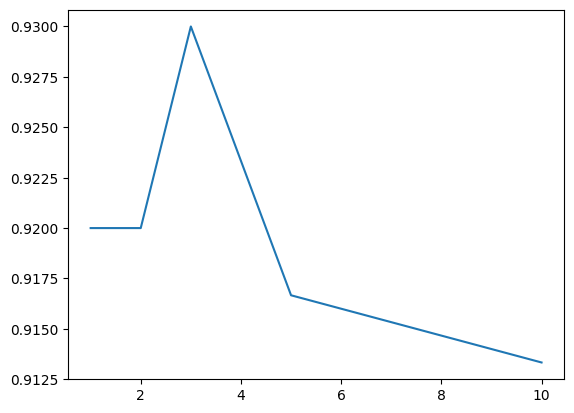

In [29]:
plt.plot(depths, accuracies)

Text(0.5, 0, 'Tree Depth')

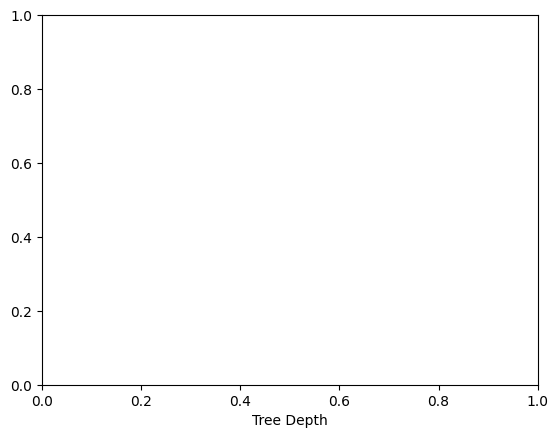

In [30]:
plt.xlabel("Tree Depth")

Text(0, 0.5, 'Accuracy')

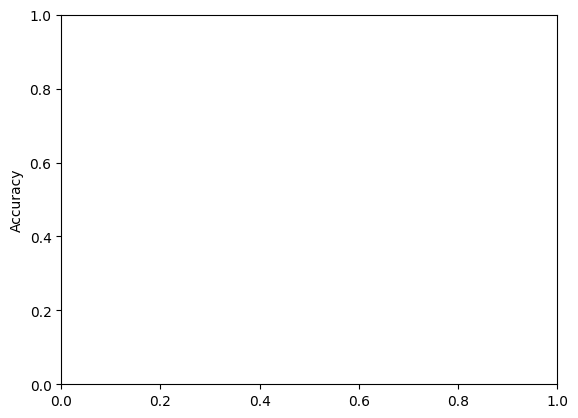

In [31]:
plt.ylabel("Accuracy")

Text(0.5, 1.0, 'Effect of Tree Depth on Accuracy')

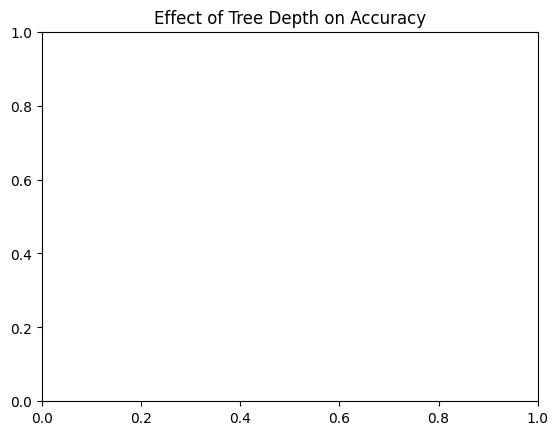

In [32]:
plt.title("Effect of Tree Depth on Accuracy")

In [34]:
for crit in ['gini', 'entropy']:
    model = DecisionTreeClassifier(criterion=crit, random_state=0)
    model.fit(X_train, Y_train)
    y_pred = model.predict(X_test)

    print("\nCriterion:", crit)
    print("Accuracy:", accuracy_score(Y_test, y_pred))


Criterion: gini
Accuracy: 0.9133333333333333

Criterion: entropy
Accuracy: 0.93


In [35]:
from sklearn import tree

In [36]:
plt.figure(figsize=(12,8))

<Figure size 1200x800 with 0 Axes>

<Figure size 1200x800 with 0 Axes>

[Text(0.40384615384615385, 0.9583333333333334, 'x[6] <= 51.5\nentropy = 1.0\nsamples = 700\nvalue = [356, 344]'),
 Text(0.19230769230769232, 0.875, 'x[6] <= 44.5\nentropy = 0.231\nsamples = 319\nvalue = [12, 307]'),
 Text(0.2980769230769231, 0.9166666666666667, 'True  '),
 Text(0.15384615384615385, 0.7916666666666666, 'entropy = 0.0\nsamples = 244\nvalue = [0, 244]'),
 Text(0.23076923076923078, 0.7916666666666666, 'x[4] <= 3.5\nentropy = 0.634\nsamples = 75\nvalue = [12, 63]'),
 Text(0.19230769230769232, 0.7083333333333334, 'x[11] <= 8.5\nentropy = 0.881\nsamples = 40\nvalue = [12, 28]'),
 Text(0.15384615384615385, 0.625, 'x[1] <= 489.5\nentropy = 0.764\nsamples = 36\nvalue = [8, 28]'),
 Text(0.07692307692307693, 0.5416666666666666, 'x[2] <= 15.5\nentropy = 0.491\nsamples = 28\nvalue = [3, 25]'),
 Text(0.038461538461538464, 0.4583333333333333, 'entropy = 0.0\nsamples = 20\nvalue = [0, 20]'),
 Text(0.11538461538461539, 0.4583333333333333, 'x[10] <= 9.0\nentropy = 0.954\nsamples = 8\nval

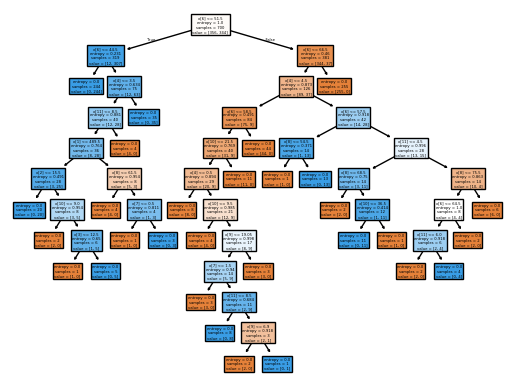

In [37]:
tree.plot_tree(model, filled=True)